# 08 · BCI Competition IV 2a: CSP and LDA

**ROBT613 · Brain–Computer Interfaces** | Teaching session + independent lab

## Goal
Use actual competition motor-imagery data, learn spatial filters inside training folds and evaluate transfer across sessions.

**Data:** BCI Competition IV 2a / BNCI2014-001, subject 1

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## How to study this notebook

This is both the classroom lesson and the independent-study workbook. Everything needed for the exercises—questions, hints, executable solutions, checks and explanations—is here. Work from top to bottom in a fresh runtime.

1. Read the question and calculate a small example on paper.
2. Write your prediction before running the next code cell.
3. Try the practice task in its workspace.
4. Continue to the worked solution and compare the reasoning, not just the number.
5. Change one parameter and explain what the result means.

**For a live class:** pause at each “Try it” heading. The solution follows in the same notebook, so no separate answer document is required. Saved figures support reading without execution; downloading real data and rerunning cells requires internet on the first run. Code comments explain each analysis statement, and longer loops are explained before execution.

**Prerequisites:** basic Python arrays, arithmetic and plotting. The symbol guide below defines the mathematical notation used here. These lessons stay at the sensor level; EEG source imaging is outside the course.

## The question for today

Fixed C3/C4 features are a useful baseline, but information may be spread across the electrode array. Common spatial patterns learns sensor combinations whose variance distinguishes classes. We examine the mathematics before fitting the Competition IV 2a data.

### By the end you should be able to

- Interpret a spatial filter as a weighted sensor sum.
- Derive the binary CSP variance-ratio objective.
- Distinguish decoding filters from sensor patterns.
- Fit CSP and tune its component count inside training folds.

**How to work:** predict each result before running it, execute one cell at a time, and write a short interpretation. The first worked examples use controlled arrays; the later walkthrough and applied practice use the dataset stated above. Practice workspaces, hints and worked solutions are placed beside the relevant methods. Complete your attempt before continuing to the reference solution.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: <dataset-cache>


## Visual route through the lesson

Follow the arrows before running the analysis. For each box, say what the input represents, what changes, and what must be preserved.

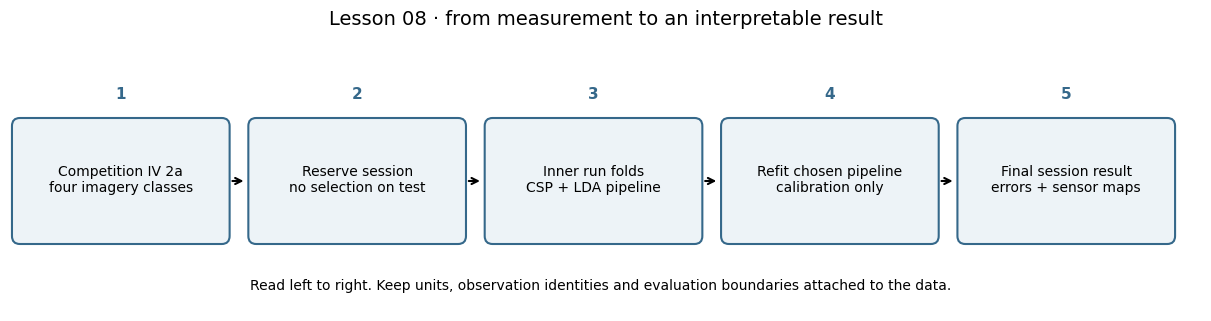

In [2]:
# Drawing code for the lesson map; no analysis data are transformed here.
from matplotlib.patches import FancyBboxPatch
map_steps=['Competition IV 2a\nfour imagery classes', 'Reserve session\nno selection on test', 'Inner run folds\nCSP + LDA pipeline', 'Refit chosen pipeline\ncalibration only', 'Final session result\nerrors + sensor maps']
fig,map_ax=plt.subplots(figsize=(12,3.1),constrained_layout=True)
map_ax.set(xlim=(-.1,12),ylim=(-.3,2.4));map_ax.axis('off')
for map_i,map_label in enumerate(map_steps):
    map_x=map_i*2.4
    map_ax.add_patch(FancyBboxPatch((map_x,.45),2.05,1.1,
        boxstyle='round,pad=0.08',facecolor='#edf3f7',edgecolor='#35688a',linewidth=1.5))
    map_ax.text(map_x+1.025,1.02,map_label,ha='center',va='center',fontsize=10)
    map_ax.text(map_x+1.025,1.83,str(map_i+1),ha='center',weight='bold',color='#35688a')
    if map_i<4:map_ax.annotate('',xy=(map_x+2.3,1),xytext=(map_x+2.13,1),arrowprops=dict(arrowstyle='->',lw=1.5))
map_ax.text(5.9,-.08,'Read left to right. Keep units, observation identities and evaluation boundaries attached to the data.',ha='center',fontsize=10)
map_ax.set_title('Lesson 08 · from measurement to an interpretable result',fontsize=14,pad=12)
plt.show()

**Read the map:** the arrows represent processing order, not permission to fit on all observations. When a stage learns parameters, keep evaluation data outside that fit. The map is also available as text: Competition IV 2a: four imagery classes → Reserve session: no selection on test → Inner run folds: CSP + LDA pipeline → Refit chosen pipeline: calibration only → Final session result: errors + sensor maps.

## Symbols and a calculation by hand

$X$: channels × time; $w$: spatial filter; $\Sigma_k$: class covariance; $\lambda$: variance ratio.

### Derive the operation before calling the library

Projected variance is $\operatorname{var}(w^TX)=w^T\Sigma w$. CSP maximizes $w^T\Sigma_1w$ subject to $w^T(\Sigma_1+\Sigma_2)w=1$. A Lagrange multiplier yields $\Sigma_1w=\lambda(\Sigma_1+\Sigma_2)w$.

For $\Sigma_1=\operatorname{diag}(4,1)$ and $\Sigma_2=\operatorname{diag}(1,4)$, the first sensor direction has ratio $4/(4+1)=0.8$ and the second $1/(1+4)=0.2$. Both extremes carry information. This derivation is binary intuition; the actual four-class MNE model uses its multiclass algorithm. Spatial filters are learned from calibration labels and must be refitted within validation folds.

### Your paper calculation

Rewrite one equation with the numerical example above. Name the input units and output units, and identify the axis being reduced or transformed.

**My calculation:** _write your intermediate steps here before continuing._

### A spatial filter operates across channels

An epoch $X\in\mathbb R^{C\times T}$ becomes $Z=WX$, where each row of $W$ contains one weight per sensor. The time axis remains intact. A spatial filter can increase a useful contrast by combining channels rather than selecting just one electrode. Its weights depend on the reference, montage, frequency band and calibration data; changing those inputs changes the meaning of the filter.

For two classes, let $\Sigma_1$ and $\Sigma_2$ be class covariance estimates. One formulation of CSP seeks

$$\max_w\frac{w^T\Sigma_1w}{w^T(\Sigma_1+\Sigma_2)w},$$

leading to the generalized eigenproblem

$$\Sigma_1w=\lambda(\Sigma_1+\Sigma_2)w.$$

Large eigenvalues identify directions with relatively more variance in class 1; small eigenvalues identify the opposite contrast. Components from both extremes can be useful. Taking log variance of the projected epoch produces features that a linear classifier can use. CSP does not directly output a class label.

### Read a small example before a large one

If class 1 has covariance `diag(4,1)` and class 2 has `diag(1,4)`, the original sensor directions already separate the variance patterns. The variance-ratio eigenvalues are 0.8 and 0.2. If both covariances are equal, there is no preferred discriminative direction. This example clarifies what the optimization seeks without asking students to interpret a large matrix blindly.

Covariance estimates can be unstable when calibration data are limited or channels are strongly correlated. Regularization moves estimates toward a better-conditioned target. The tradeoff is bias versus variance; it is not a guarantee of higher held-out accuracy. Our pipeline uses regularized covariance and tunes only a small candidate set.

### Binary derivation, four-class experiment

Competition IV 2a contains four movement-imagery classes. The binary derivation provides intuition; MNE's multiclass implementation uses a multiclass covariance decomposition and component ordering, rather than pretending that all non-left trials are a single homogeneous class. Inspect the actual label set and confusion matrix. A score of 0.25 is the balanced-accuracy chance reference for four equally weighted class recalls, not 0.5.

A filter is a weight vector used for discrimination. A sensor pattern describes how a component is expressed across measured sensors. Large decoding weights can suppress correlated noise and should not be read directly as a map of neural activation. The topographies here visualize sensor patterns only. They are not EEG source images and involve no forward or inverse model.

### Why CSP belongs in the pipeline

CSP uses class labels to learn the representation. Fitting it on all trials before cross-validation leaks held-out labels even if the final classifier is refit in each fold. Place CSP and LDA in the same scikit-learn pipeline. Inner grouped folds choose the component count using calibration runs, then one untouched session estimates transfer to a later recording session. Every preprocessing choice that is selected using labels belongs to the same training-only boundary.

## Visual intuition · Visualize the covariance contrast CSP seeks

**Try it:** Which projection direction has larger variance for each class? Predict the two binary variance ratios.

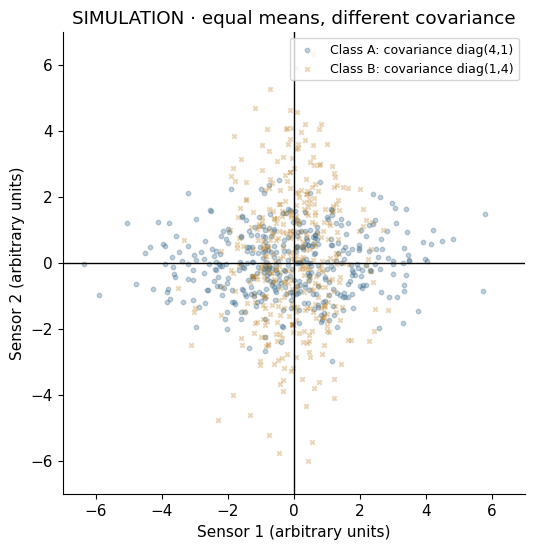

In [3]:
vis_rng=np.random.default_rng(613)
vis_a=vis_rng.multivariate_normal([0,0],np.diag([4,1]),400)
vis_b=vis_rng.multivariate_normal([0,0],np.diag([1,4]),400)
fig,ax=plt.subplots(figsize=(6,6))
ax.scatter(*vis_a.T,s=10,alpha=.3,label='Class A: covariance diag(4,1)',color='#35688a')
ax.scatter(*vis_b.T,s=10,alpha=.3,label='Class B: covariance diag(1,4)',color='#b87714',marker='x')
ax.axhline(0,color='black',lw=1);ax.axvline(0,color='black',lw=1)
ax.set(xlim=(-7,7),ylim=(-7,7),aspect='equal',xlabel='Sensor 1 (arbitrary units)',ylabel='Sensor 2 (arbitrary units)',title='SIMULATION · equal means, different covariance')
ax.legend(loc='upper right',fontsize=9);plt.show()

### Worked interpretation

The class means are the same, but their spreads differ. A mean-based classifier on raw instantaneous values cannot exploit this in the same way as projected variance features. Directions along the axes yield ideal ratios 0.8 and 0.2; sample estimates fluctuate.

## Guided practice 1 · a spatial projection

Calculate a sensor difference and a sensor average with one matrix multiplication.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [4]:
demo_X=np.array([[1.,2.,3.],[3.,2.,1.]])
demo_W=np.array([[1.,-1.],[.5,.5]])
demo_Z=demo_W@demo_X
print('Projected signals:\n',demo_Z)
assert np.allclose(demo_Z[1],[2,2,2])

Projected signals:
 [[-2.  0.  2.]
 [ 2.  2.  2.]]


### Why this result makes sense

Rows of W combine sensors; they do not convolve over time. Write the matrix dimensions beside each operation.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 2 · solve binary CSP

Use diagonal class covariances and inspect the generalized eigenvalues.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [5]:
from scipy.linalg import eigh
demo_S1=np.diag([4.,1.]);demo_S2=np.diag([1.,4.])
demo_eig,demo_vec=eigh(demo_S1,demo_S1+demo_S2)
print('Variance ratios:',demo_eig)
assert np.allclose(demo_eig,[.2,.8])

Variance ratios: [0.2 0.8]


### Why this result makes sense

The eigenvectors are normalized under the pooled covariance, not necessarily to unit Euclidean norm.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 3 · no class difference

Repeat the eigenproblem with identical covariance matrices.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [6]:
demo_same=np.array([[2.,.3],[.3,1.]])
print('Equal-covariance ratios:',eigh(demo_same,2*demo_same)[0])

Equal-covariance ratios: [0.5 0.5]


### Why this result makes sense

Every direction has ratio 0.5. A numerical solver can still return vectors, but those vectors do not imply class information.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 4 · shrink a covariance

Move an ill-conditioned covariance toward a scaled identity and compare condition numbers.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [7]:
demo_cov=np.diag([1.,.00001])
demo_target=np.trace(demo_cov)/2*np.eye(2)
for alpha in [0,.1,.5]:
    regularized=(1-alpha)*demo_cov+alpha*demo_target
    print(alpha,np.linalg.cond(regularized))

0 99999.99999999999
0.1 18.996400683870064
0.5 2.999920002399928


### Why this result makes sense

Better conditioning stabilizes matrix operations. Excessive shrinkage can also erase discriminative covariance structure.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Practice 1 · Variance-ratio objective

Implement variance_ratio for a vector and two class covariance matrices.

**Try it:** complete the function below before reading its solution. The template deliberately returns None so that an unfinished attempt does not interrupt the rest of the lesson.

In [8]:
def variance_ratio(w, covariance_a, covariance_b):
    # TODO: evaluate the binary CSP objective.
    return None

### Hint

Use the equation above and keep the trial/channel axes intact unless the requested output removes them. Test the smallest example by hand first.

### Worked solution

Compare this implementation with your attempt. The next cell checks the reference answer on a concrete numerical case.

In [9]:
def variance_ratio(w,covariance_a,covariance_b):
    return (w@covariance_a@w)/(w@(covariance_a+covariance_b)@w)

In [10]:
answer=variance_ratio(np.array([1.,0.]),demo_S1,demo_S2)
if answer is not None:
    assert np.isclose(answer,.8); print('CSP objective check passed.')
else: print('Exercise pending: implement variance_ratio.')

CSP objective check passed.


## Apply the ideas to the complete pipeline

The next stages use the real recording or the explicitly labeled simulation described in the lesson. Keep preprocessing, feature extraction and evaluation decisions visible. Read each stage’s explanation before running its code.

### Method reference for the pipeline

Common spatial patterns finds directions with different class variances. For two class covariances $C_1,C_2$, solve $C_1w=\lambda(C_1+C_2)w$. Eigenvectors at opposite ends emphasize either class. A typical feature is $z_j=\log\mathrm{Var}(w_j^TX)$; optional variance normalization changes the definition. MNE supports multiclass CSP with approximate joint diagonalization; the binary eigenproblem explains the intuition but is not the complete four-class algorithm.

CSP is supervised: fitting it on all epochs before cross-validation leaks test labels. Keep CSP and LDA in one scikit-learn pipeline. Spatial **filters** transform sensors into components; spatial **patterns** describe how components project to sensors and are usually more suitable for physiological interpretation.

BNCI2014-001 corresponds to BCI Competition IV dataset 2a: left hand, right hand, feet and tongue imagery. It is fetched by MOABB and represented as MNE epochs. The original competition split and a modern cross-session reanalysis are not identical evaluation claims. Here session 1 is calibration and session 2 is held out; we report a course reanalysis, not an official competition submission.

## Load competition data
Use one participant for a bounded CPU lesson. Expand to all nine participants only after validating the protocol.

The competition loader returns four imagery labels and session/run metadata. One participant keeps the classroom example bounded; the final session remains untouched during selection.

### Step 1.1 · trace the next operation

**1.** Import the named tools used in this step.

**2.** Import the named tools used in this step.

**3.** Store this intermediate result so the next operation can be traced and inspected.

**4.** Declare the imagery class set, band and analysis interval before loading.

**5.** Expose the numerical array; EEG values are in volts and the final axis is time.

**6.** Expose the numerical array; EEG values are in volts and the final axis is time.

**7.** Make an explicit NumPy vector while preserving its current row order.

In [11]:
# Import the named tools used in this step.
from moabb.datasets import BNCI2014_001
# Import the named tools used in this step.
from moabb.paradigms import MotorImagery
# Store this intermediate result so the next operation can be traced and inspected.
dataset = BNCI2014_001()
# Declare the imagery class set, band and analysis interval before loading.
paradigm = MotorImagery(n_classes=4, fmin=8, fmax=30, tmin=0.5, tmax=3.5)
# Expose the numerical array; EEG values are in volts and the final axis is time.
epochs, y, meta = paradigm.get_data(dataset=dataset, subjects=[1], return_epochs=True)
# Expose the numerical array; EEG values are in volts and the final axis is time.
X = epochs.get_data(copy=True)
# Make an explicit NumPy vector while preserving its current row order.
y = np.asarray(y)

Choosing from all possible events


<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = mak

<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = mak

<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")


### Step 1.2 · trace the next operation

**1.** Keep one label or grouping identifier per trial in exactly the same order as the EEG array.

**2.** Keep one label or grouping identifier per trial in exactly the same order as the EEG array.

**3.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

**4.** Check a required invariant now so a silent alignment or numerical error cannot propagate.

**5.** Create an explicit partition mask; use the same mask for data, labels and metadata.

**6.** Create an explicit partition mask; use the same mask for data, labels and metadata.

In [12]:
# Keep one label or grouping identifier per trial in exactly the same order as the EEG array.
sessions = meta.session.astype(str).to_numpy()
# Keep one label or grouping identifier per trial in exactly the same order as the EEG array.
groups = (meta.session.astype(str) + '/' + meta.run.astype(str)).to_numpy()
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print(pd.crosstab(sessions, y))
# Check a required invariant now so a silent alignment or numerical error cannot propagate.
assert len(np.unique(sessions)) == 2
# Create an explicit partition mask; use the same mask for data, labels and metadata.
train = sessions == sorted(np.unique(sessions))[0]
# Create an explicit partition mask; use the same mask for data, labels and metadata.
test = ~train

col_0   feet  left_hand  right_hand  tongue
row_0                                      
0train    72         72          72      72
1test     72         72          72      72


### Inspect and interpret

Check the number of classes, trials per session and distinct calibration runs. The chance reference for balanced accuracy depends on the four-class label set.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 2 · Inspect the session and run hierarchy

**Try it:** Count trials per session and class, and count distinct calibration runs. Why does the hierarchy matter?

**My reasoning / hand calculation:** _write here._

In [13]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

Inner folds need calibration-run identifiers; the final session stays outside them.

### Worked solution

Run the following calculation after attempting your own version.

In [14]:
print(pd.crosstab(pd.Series(sessions,name='session'),pd.Series(y,name='class')))
print('Calibration run groups:',np.unique(groups[train]))
assert set(sessions[train]).isdisjoint(set(sessions[test]))

class    feet  left_hand  right_hand  tongue
session                                     
0train     72         72          72      72
1test      72         72          72      72
Calibration run groups: ['0train/0' '0train/1' '0train/2' '0train/3' '0train/4' '0train/5']


### Interpret and check

The session split defines the final transfer claim. Calibration run groups support model selection within that boundary. A random split of all trials would answer a different, easier recording-context question.

## Tune on training runs, test once
Shrinkage stabilizes covariance estimates. Component count is selected only inside the calibration session.

Grid search evaluates a small component-count set using calibration-run groups. Because CSP is inside the pipeline, its supervised spatial filters are relearned in each inner fold. The selected pipeline is refitted on calibration data before the session test.

### Step 2.1 · trace the next operation

**1.** Import the named tools used in this step.

**2.** Keep learned preprocessing and the classifier inside the same fitting boundary.

**3.** Hold entire recording groups out rather than mixing neighboring trials.

**4.** Choose among declared candidates using only inner validation within calibration data.

**5.** Fit candidate pipelines on calibration folds; groups constrain the inner partitions.

**6.** Apply the already-fitted estimator to observations excluded from fitting.

**7.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

In [15]:
# Import the named tools used in this step.
from mne.decoding import CSP
# Keep learned preprocessing and the classifier inside the same fitting boundary.
pipeline = make_pipeline(CSP(n_components=4, reg='ledoit_wolf', log=True, norm_trace=False), LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))
# Hold entire recording groups out rather than mixing neighboring trials.
inner = GroupKFold(n_splits=3)
# Choose among declared candidates using only inner validation within calibration data.
search = GridSearchCV(pipeline, {'csp__n_components': [2, 4, 6]}, cv=inner, scoring='balanced_accuracy', n_jobs=1)
# Fit candidate pipelines on calibration folds; groups constrain the inner partitions.
search.fit(X[train], y[train], groups=groups[train])
# Apply the already-fitted estimator to observations excluded from fitting.
pred = search.predict(X[test])
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print('Training-only choice:', search.best_params_)

Training-only choice: {'csp__n_components': 4}


### Step 2.2 · trace the next operation

**1.** Average class recalls so majority-class frequency does not dominate the score.

**2.** Show which true classes are confused at the current decision rule.

**3.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**4.** Render the completed figure and inspect labels, units and the comparison.

Held-out session balanced accuracy: 0.7847222222222222


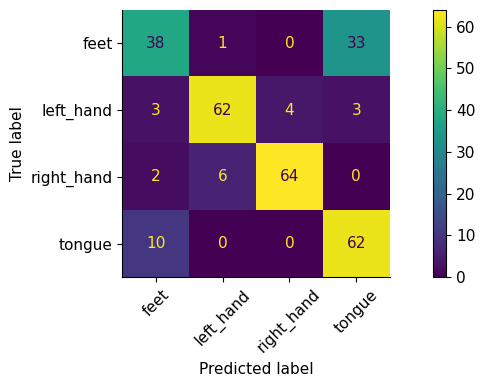

In [16]:
# Average class recalls so majority-class frequency does not dominate the score.
print('Held-out session balanced accuracy:', balanced_accuracy_score(y[test], pred))
# Show which true classes are confused at the current decision rule.
ConfusionMatrixDisplay.from_predictions(y[test], pred, xticks_rotation=45)
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
plt.tight_layout()
# Render the completed figure and inspect labels, units and the comparison.
plt.show()

### Inspect and interpret

Read the selected component count and the full confusion matrix. Separate the inner selection score from the final session score; they describe different stages of the experiment.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 3 · Inspect model selection without touching the test result

**Try it:** Display inner-validation means for the candidate CSP component counts. Which count was selected and why?

**My reasoning / hand calculation:** _write here._

In [17]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

Use cv_results_; do not rank candidates by final-session accuracy.

### Worked solution

Run the following calculation after attempting your own version.

In [18]:
lab_search=pd.DataFrame(search.cv_results_)
print(lab_search[['param_csp__n_components','mean_test_score','std_test_score','rank_test_score']].sort_values('rank_test_score'))
print('Chosen using calibration only:',search.best_params_)

   param_csp__n_components  mean_test_score  std_test_score  rank_test_score
1                        4         0.756944        0.017705                1
2                        6         0.753472        0.019642                2
0                        2         0.729167        0.034021                3
Chosen using calibration only: {'csp__n_components': 4}


### Interpret and check

GridSearchCV ranks candidates by mean inner-validation balanced accuracy. The spread reflects those folds, not an independent participant confidence interval. The selected configuration is then refitted on calibration data before the final session is scored.

## Practice 4 · Find a leakage bug in a proposed shortcut

**Try it:** A student fits CSP on X and y once, then cross-validates LDA on its output. What leaked?

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

CSP uses labels to estimate the representation.

### Worked solution

The held-out labels influenced the covariance contrast and spatial filters before cross-validation. Refitting only LDA does not undo that information flow. Place CSP and LDA in the same pipeline so both are fitted afresh using each training fold.

## Inspect learned patterns
These maps use the calibration-fitted CSP only. They do not establish a causal neural generator.

Plot sensor patterns from the calibration-fitted model. MNE’s component scale and sign conventions are arbitrary, so the maps are interpreted as relative sensor distributions rather than absolute neural activation.

### Step 3.1 · trace the next operation

**1.** Store this intermediate result so the next operation can be traced and inspected.

In [19]:
# Store this intermediate result so the next operation can be traced and inspected.
csp = search.best_estimator_.named_steps['csp']

### Step 3.2 · trace the next operation

**1.** Create axes; plotting changes the display, not the analyzed data.

**2.** Plot each named condition on comparable axes without changing its observations.

**3.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**4.** Render the completed figure and inspect labels, units and the comparison.

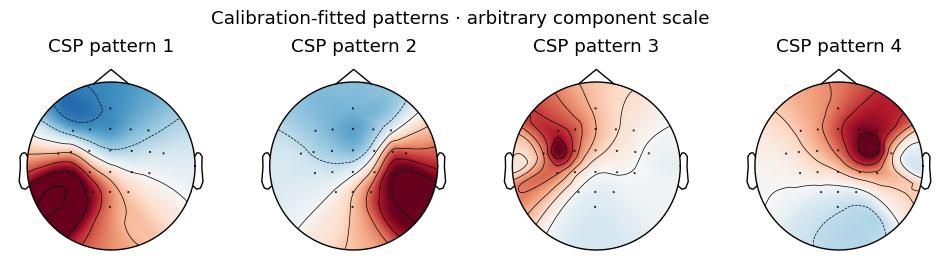

In [20]:
# Create axes; plotting changes the display, not the analyzed data.
fig, axes = plt.subplots(1, csp.n_components, figsize=(3 * csp.n_components, 3))
# Plot each named condition on comparable axes without changing its observations.
for component, ax in enumerate(np.atleast_1d(axes)):
    mne.viz.plot_topomap(csp.patterns_[component], epochs.info, axes=ax, show=False)
    ax.set_title(f'CSP pattern {component + 1}')
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
fig.suptitle('Calibration-fitted patterns · arbitrary component scale')
# Render the completed figure and inspect labels, units and the comparison.
plt.show()

### Step 3.3 · trace the next operation

**1.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

In [21]:
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print('Training epochs:', int(train.sum()), 'test epochs:', int(test.sum()))

Training epochs: 288 test epochs: 288


### Inspect and interpret

State which channels contribute strongly and whether the map suggests a plausible sensor-level contrast. Do not assign the component to an anatomical brain generator.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 5 · Distinguish patterns from filters

**Try it:** Can the largest CSP coefficient be read as the location of the most active brain region? Explain.

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

A decoding weight may suppress correlated nuisance activity.

### Worked solution

No. Filters are weights used to form discriminative combinations; patterns describe how components project onto measured sensors. Neither is anatomical source localization. Signs and scales are arbitrary, and this course deliberately uses sensor-level interpretations only.

## Practice 6 · explain the complete method

Without looking back, explain the measurement, transformation, feature or summary, and the evaluation boundary. Include one failure mode and one claim the result does not establish.

**My explanation:** _write here._

### Worked answer · compare your reasoning

CSP learns label-dependent variance contrasts, so it belongs inside the training pipeline. The binary eigenproblem explains the intuition; the experiment has four classes. Sensor patterns help inspect a model but are not anatomical source localization.

## If your result is different

If covariance rank is deficient, inspect reference, channel selection and regularization. Do not solve it by fitting CSP to the test data. Pattern signs and scales are arbitrary.

If a dataset download fails, read the error and retry when the public host is reachable; do not silently replace real data with simulated values. If a notebook cell refers to an undefined variable, restart the kernel and run the preceding cells in order. Numerical scores can vary slightly with library versions; record versions and compare the protocol before concluding that a method changed.

## Can you now do this independently?

- Explain each arrow in the lesson map and the units at its boundaries.
- Reproduce the hand calculation and point to its corresponding code.
- Interpret the figures without turning a descriptive pattern into an unsupported causal claim.
- Complete a practice task before reading its worked solution.
- State which choices were fixed and which were learned from calibration data.

If one item is unclear, return to the associated figure or practice section before the next lesson.

## Next steps and sources
[Competition 2a via MOABB](https://moabb.neurotechx.com/docs/generated/moabb.datasets.BNCI2014_001.html) · [MNE CSP](https://mne.tools/stable/generated/mne.decoding.CSP.html).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.